# Atmospheric Transmission at Short Wavelengths

An important consideration for remote sensing is the proportion of total electromagnetic radiation that can make it through Earth's atmosphere. Only the wavelengths of the electromagnetic spectrum which are largely transmissible through the atmosphere can be used for remote sensing observations of the ocean surface. In this notebook, we'll examine the transmission of electromagnetic radiation through the atmosphere at short wavelengths - here designed to encompass the UV, visible, shortwave infrared, and part of the midwave infrared regions of the spectrum between 200 and 4000 nm.

Since we'll be making several plots in this notebook, we'll begin by importing modules to read, process, and plot data:

In [28]:
import netCDF4 as nc4
import numpy as np
import matplotlib.pyplot as plt

## Molecular Extinction

To quantify transmission through the atmosphere, we'll first define **molecular extinction**. Consider a radiance $L$ at a height $z$ in the atmosphere which passes through a section of atmosphere with height $\Delta z$. The radiance has a spectral distribution given by Planck's Law (i.e. $L(\lambda)$) but we'll omit the $\lambda$ dependence in the equations above for clarity. The following diagram depicts this scenario of the irradiance passing through the section of atmosphere:

```{figure} ../images/fundamentals/molecular_extinction.png
---
height: 300px
name: molecular-extinction
---
Schematic description of molecular extinction.
```

When this irradiance passes through a gas of height $\Delta z$, it is reduced as a result of both absorption and scattering by the gas. The absorption and scattering will depend on the composition of the gas and can be parameterized using coefficients $\kappa_A$ and $\kappa_S$, respectively. These coefficients can be combined into an *effective* extinction coefficient $\kappa_E$ (in units of m$^{-1}$). Using this definition, we can see that the change in irradiance through the section of gas can be written as

$$
\begin{align*}
\Delta L &= \kappa_E L(z) \Delta z\\
\Longrightarrow \frac{\Delta L}{\Delta z} &= -\kappa_E L(z)\\
\Longrightarrow \frac{\partial L}{\partial z} &= -\kappa_E L(z)
\end{align*}
$$

Solving for this differential equation, we can compute the cumulative extinction of irradiance as it passes through a section of height $z_H$ in the atmosphere as:

$$
L(z) = L_0\text{exp}\left[-\int_0^{z_H} \kappa_E(z) \, dz \right]
$$

When integrated over the entire atmosphere, the term in the exponential, i.e.

$$
\tau = \int_0^{z_H} \kappa_E(z) \, dz
$$

is defined as the *optical depth* in the atmosphere. Note again that $L$ is a function of wavelength. 

The **transmittance** is defined in terms of the optical depth as

$$
t = e^{-\tau}
$$

Note that since optical depth has values in the range $[0, \infty)$, transmittance has values in the range $[0, 1]$, or between 0% and 100%.



## Transmission in the Atmosphere

To examine atmospheric transmission, we will read in a dataset generated using [Py6S](https://py6s.readthedocs.io/en/latest/) (www.doi.org/10.1016/j.cageo.2012.08.002), the Python-wrapped version of Second Simulation of the Satellite Signal in the Solar Spectrum (6S) model used to quantify reflection, absorption, and transmission of electromagnetic radiation for wavelengths in the UV, visible, and shortwave infrared regions of the spectrum (www.doi.org/10.1109/36.581987). This has been bundled into a convenient netCDF file for this notebook:

In [29]:
# plot the atmospheric transmission data
ds = nc4.Dataset('../data/molecular_transmission.nc')
h2o = ds.variables['water_vapor'][:]
co2 = ds.variables['carbon_dioxide'][:]
o2 = ds.variables['oxygen'][:]
o3 = ds.variables['ozone'][:]
n2o = ds.variables['nitrous_oxide'][:]
ch4 = ds.variables['methane'][:]
rayleigh = ds.variables['rayleigh_scattering'][:]
gas = ds.variables['global_gas'][:]
ds.close()
wavelengths = np.arange(0.2,4.00,0.01)

Next, since we will explore several plots on this page, let's define a generic plotting function that can be used many times over:

In [30]:
def plot_transmission_figure(wavelengths, transmission, title):
    plt.rcParams['figure.facecolor'] = 'white'
    plt.rcParams['savefig.facecolor'] = 'white'
    fig = plt.figure(figsize=(8,4))
    plt.plot(np.log10(wavelengths),  transmission*100)
    xticks = np.log10(np.array([0.2, 0.38, 0.55, 0.7, 1, 2, 3, 4]))
    plt.gca().set_xticks(xticks)
    xtickslabels = ['200', '380', '550', '700', '1000', '2000', '3000', '4000']
    plt.gca().set_xlim([np.log10(0.2), np.log10(4)])
    plt.gca().set_xticklabels(xtickslabels)
    plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
    plt.ylabel('Atmospheric Transmission (%)')
    plt.xlabel('Wavelength (nm)')
    plt.title(title)
    plt.ylim([-5,105])
    plt.show()

## Total Atmospheric Transmission

Using the plotting function above, let's plot the total transmission by gases in the atmosphere:

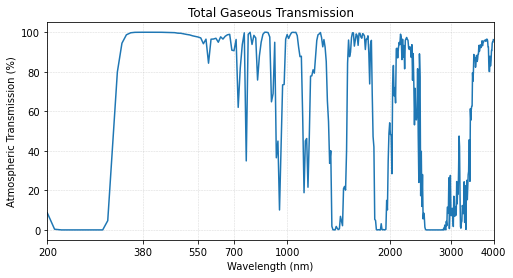

In [31]:
plot_transmission_figure(wavelengths, gas,
                         title = 'Total Gaseous Transmission')

As we can see, there are various parts of the electromagnetic spectrum in which no light makes it through the atmosphere. For example, there is a large region near in the UV portion of the spectrum between 200 and 300 nm in which there is very little transmission. Similarly, there are other portions of the spectrum where there are **atmospheric windows** - portions of the spectrum in which nearly all light is transmissible through the atmosphere. 

In addition to molecular absorption, gases also scatter light in the atmosphere. An important form of scattering in the atmosphere is *Rayleigh scattering* which can be visualized as:

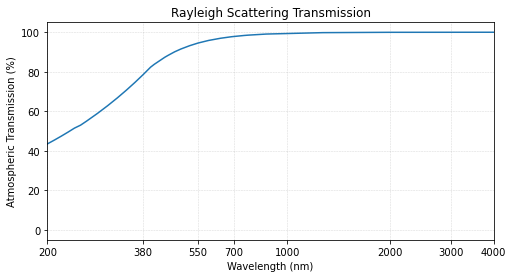

In [32]:
plot_transmission_figure(wavelengths, rayleigh,
                         title = 'Rayleigh Scattering Transmission')

In this curve, we see that light at shorter wavelengths is scattered more strongly than light at longer wavelengths.

```{note}
Why is the sky blue? One of the main reasons that our sky appears blue during regular daylight hours is that shorter wavelengths, including those in blue region of the visible spectrum, are scattered more than other wavelengths. Note that this also includes violet light, but there are higher quantities of blue light relative to violet light from our Sun (Planck's Law!) and our eyes are more sensitive to blue light than violet light.
```

To estimate the total effect of the atmosphere on radiance passing through it, we can multiply the atmospheric transmission by the total irradiance from the sun. Approximating the sun as a blackbody, [Planck's Law](https://profmikewood.github.io/ocean_remote_sensing_book/blackbodies/#plancks-law) allows us to estimate the total radiation:

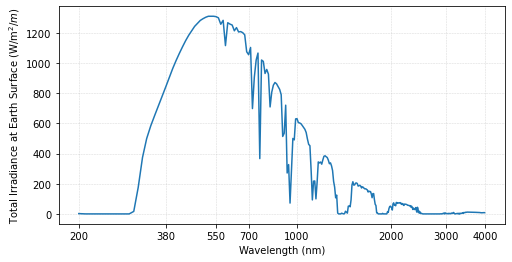

In [33]:
# Planck's Law
T = 5525
kB = 1.380649e-23
h = 6.626e-34
c = 299792458
Fp = (2*h*c**2/(wavelengths/1e6)**5) * (1/(np.exp(h*c/((wavelengths/1e6)*kB*T))-1))

# modify to account for earth-sun difference
r_S = 6.96e8 # radius of sun
d_ES = 1.5e14 # distance from Earth to Sun
Fp_Earth = np.pi*Fp*(r_S**2)/(d_ES**2)

# make a figure
fig = plt.figure(figsize=(8,4))
plt.plot(np.log10(wavelengths),  Fp_Earth*gas*rayleigh)
xticks = np.log10(np.array([0.2, 0.38, 0.55, 0.7, 1, 2, 3, 4]))
plt.gca().set_xticks(xticks)
xtickslabels = ['200', '380', '550', '700', '1000', '2000', '3000', '4000']
plt.gca().set_xticklabels(xtickslabels)
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.ylabel('Total Irradiance at Earth Surface (W/m$^2/m$)')
plt.xlabel('Wavelength (nm)')
plt.show()

As we can see, the irradiance at the Earth's surface is a function of both the total irradiance incident on Earth from the Sun as well as the fraction that can make it through the atmosphere - and this provides big constraints on the wavelengths of light we can measure using sensors on satellites and other platforms.

## Transmission by Atmospheric Constituents
As we saw above, there are certain "windows" of transmittance through the atmosphere - these are largely dependent on which gases are present and how they interact with electromagnetic radiation. Some important atmospheric constituents are as follows:

| Gas Name | Concentration |
|----------|---------|
| Nitrogen (N$_2$) | 78% |
| Oxygen (O$_2$) | 21% |
| Argon (Ar) | 0.93% |
| Carbon Dioxide (CO$_2$) | 420 ppm (and rising) |
| Water Vapor (H$_2$O) | Variable |
| Ozone (O$_3$) | Variable |
| Nitrous Oxide (N$_2$O) | 0.338 ppm |
| Methane (CH$_4$) | 1.9 ppm |
| Carbon Monoxide (CO) | 0.1 ppm |

Next, we'll examine the transmission curves for many of the common atmospheric gases.

### Oxygen
The transmission curve for oxygen is shown below:

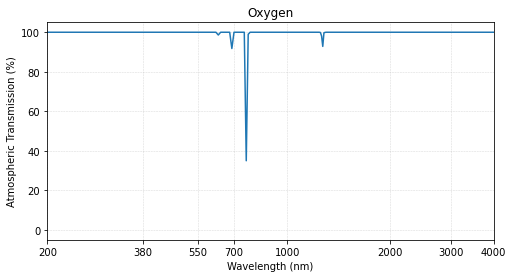

In [34]:
plot_transmission_figure(wavelengths, o2,
                         title = 'Oxygen')

As we can see, oxygen interacts very little with electromagnetic radiation in the visible and shortwave infrared regions of the spectrum. There are only a few small portions of the spectrum that influence overall transmission.

### Carbon Dioxide
Next, we'll take a look at the transmission curves for CO$_2$:

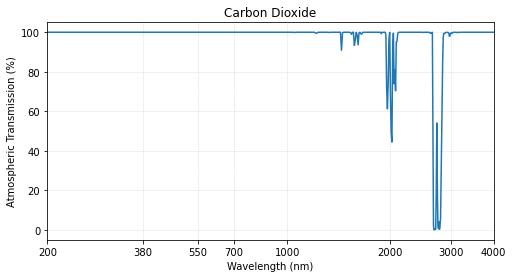

In [35]:
plot_transmission_figure(wavelengths, co2,
                         title = 'Carbon Dioxide')

Similar to O$_2$, we see near-100% transmission in most of the visible portion of the spectrum. However, CO$_2$ starts to interact more with radiation in the shortwave infrared portion of the spectrum, particularly at wavelengths between 2 and 3 $\mu$m.

### Water Vapor
Unlike O$_2$ and CO$_2$, water vapor interacts greatly with electromagnetic radiation in the shortwave infrared as well as to some extent in the visible portion of the spectrum:

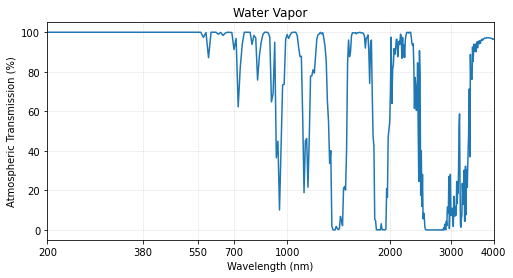

In [36]:
plot_transmission_figure(wavelengths, h2o,
                         title = 'Water Vapor')

As we can see from the transmission curve above, there are several portions of the water vapor spectrum where there is 0% transmission. This turns out to be an important consideration for Earth-observing satellites as well as ground-based telescopes observing the cosmos. Note that water vapor here refers to gaseous water rather than clouds, which are largely made up of liquid water droplets or ice crystals.

### Ozone
O$_3$ is a common gas in the stratosphere overlying the troposphere. Let's have a look at its spectrum:

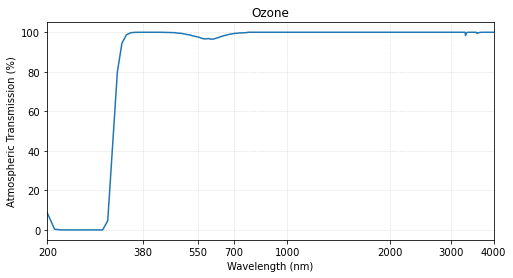

In [37]:
plot_transmission_figure(wavelengths, o3,
                         title = 'Ozone')

As we can see, O$_3$ is mostly transparent in the visible and shortwave infrared but it interacts strongly with ultraviolet light. This property makes O$_3$ an important gas for reducing exposure to harmful radiation that causes skin cancer in humans as UV radiation is responsible for cancerous growth in skin cells.

### Methane
Methane (CH$_4$) is gas produced by the agricultural and "natural" gas industries and is a common constituent in our atmosphere.

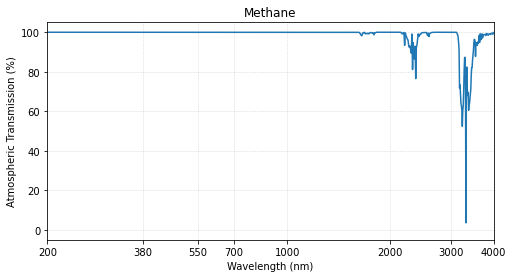

In [38]:
plot_transmission_figure(wavelengths, ch4,
                         title = 'Methane')

In the plot above, we can see that methane is transparent in the UV and visible portions of the spectrum but, like CO$_2$, begins to interact with radiation at the shortwave infrared wavelengths.

### Nitrous Oxide
N$_2$O, another common gas in our atmosphere has small regions of interaction in the shortwave infrared region of the spectrum:

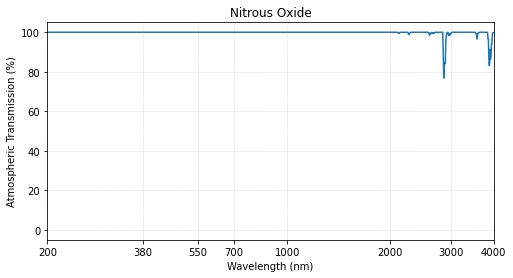

In [39]:
plot_transmission_figure(wavelengths, n2o,
                         title = 'Nitrous Oxide')

## Key Takeaways

Several important observations can be made by examining the plots above:

- First, it turns out that many of the atmospheric "wiggles" in the total transmission spectrum arise from water vapor - particularly in the shortwave infrared region of the spectrum. Since water vapor is highly variable in the atmosphere, this has implications for radiation at the ocean surface.
- Second, we observe that ozone absorbs strongly in UV part of spectrum. This gas is important for protecting life on the planet since UV radiation is harmful to cell reproduction.
- Third, the main greenhouse gases shown above - carbon dioxide, methane, water vapor, and nitrous oxide - are "invisible" in the visible range of the spectrum, but start to interact with radiation at the longer wavelengths.